# Customer Segmentation 🛍️
In this project, we aim to segment mall customers based on their purchasing behavior. We will implement, visualize, and compare three clustering algorithms: K-Means, Hierarchical Clustering, and DBSCAN.

## 📦 Importing Libraries and Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
import joblib

# Set dark theme for plots
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#121212", "figure.facecolor": "#121212", "grid.color": "#333333"})

# Load the dataset
df = pd.read_csv('Customer.csv')
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 🧹 Data Preprocessing
We drop `CustomerID` because it provides no analytical value. To achieve clear behavioral segments, we will focus on `Annual Income` and `Spending Score`. We then apply `StandardScaler` to ensure all features contribute equally to the distance metrics.

In [2]:
# Select primary features for behavioral segmentation
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 🧩 K-Means Clustering
First, we use the Elbow Method and Silhouette Scores to determine the optimal number of clusters (K).

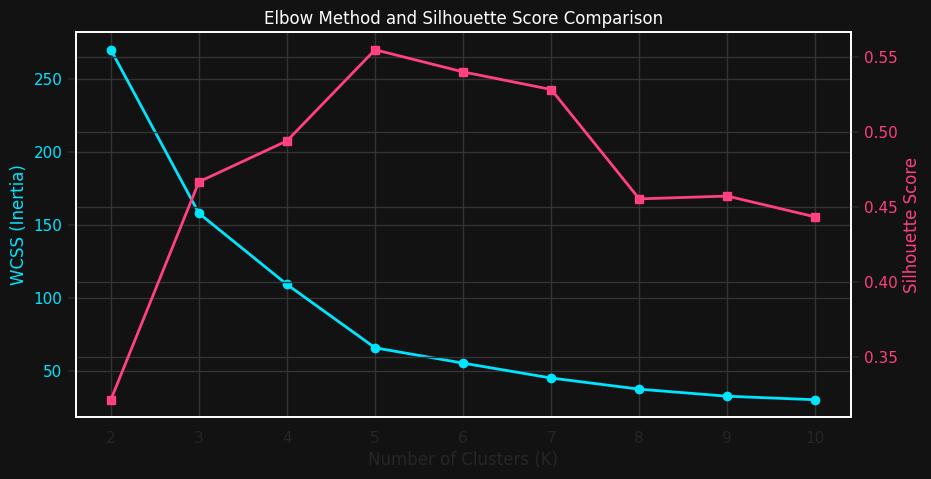

In [3]:
wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))

color = '#00e5ff'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS (Inertia)', color=color)
ax1.plot(k_range, wcss, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#ff4081'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, sil_scores, marker='s', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Method and Silhouette Score Comparison', color='white')
plt.show()